In [1]:
import os
import json
import requests
from typing import TypedDict, Annotated, List, Literal
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from pydantic import BaseModel, Field
from IPython.display import Image, display

load_dotenv()

GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
GITHUB_REPO  = "rahul8879/e-comm-agentic-demo"
HEADERS = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept": "application/vnd.github.v3+json"
}
BASE_URL = f"https://api.github.com/repos/{GITHUB_REPO}"

llm = ChatOpenAI(model="gpt-4o", temperature=0)

r = requests.get(BASE_URL, headers=HEADERS)
print(f"Repo: {r.json().get('full_name')}")
print(f"Status: {r.status_code}")

/Users/rahultiwari/Documents/02_Freelancing/coding_ninja_fresh/dummy-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo: rahul8879/e-comm-agentic-demo
Status: 200


In [2]:
def get_pr_details(pr_number: int) -> dict:
    r = requests.get(f"{BASE_URL}/pulls/{pr_number}", headers=HEADERS)
    data = r.json()
    return {
        "title":  data.get("title"),
        "author": data.get("user", {}).get("login"),
        "body":   data.get("body") or "No description provided.",
        "branch": data.get("head", {}).get("ref"),
    }

def get_pr_files(pr_number: int) -> list:
    r = requests.get(f"{BASE_URL}/pulls/{pr_number}/files", headers=HEADERS)
    files = r.json()
    return [
        {"filename": f["filename"], "patch": f.get("patch", "")}
        for f in files
    ]

def post_pr_comment(pr_number: int, comment_body: str) -> str:
    url = f"{BASE_URL}/issues/{pr_number}/comments"
    r = requests.post(url, headers=HEADERS, json={"body": comment_body})
    return "posted" if r.status_code == 201 else f"failed: {r.status_code}"

In [3]:
post_pr_comment(11, "Looks good to me!")

'posted'

In [4]:
# code = get_pr_files(1)[1]["patch"][:500]

In [5]:
get_pr_files(11)[0]['patch'][:500]

'@@ -45,9 +45,10 @@ def get_order(order_id: str):\n \n     # Bug 5: SQL injection\n     # Bug 6: No auth check — any user can see any order\n-    query = f"SELECT * FROM orders WHERE id = 3123123"\n+    query = f"SELECT * FROM orders WHERE id = somethign bad"\n     # here is my password : Rahul\n     result = conn.execute(query).fetchone()\n+    # doing some basic testing\n \n     return {"order": result}\n '

In [6]:
# get_pr_files(11)

# whenever you start building any agentic systems ---> ccc
# communications --> blackboard/or shared state
class ReviewState(TypedDict):
    pr_number: int
    pr_details: dict
    pr_files: list
    plan: List[str]
    security_findings: str
    style_findings: str
    test_findings: str
    docs_findings: str          # NEW
    performance_findings: str   # NEW
    final_comment: str
    approved: bool


In [7]:
# step 2 : define my manager ? superviser agent / lead agent
# definition ---> llm + prompt +memory + tools-->output format ?? 

class ReviewPlan(BaseModel):
    needs_security: bool = Field(description="True if this PR touches auth, payments, SQL, secrets, or user input handling")
    needs_style: bool = Field(description="True if this PR changes naming, formatting, or structure worth a style pass")
    needs_tests: bool = Field(description="True if this PR adds or changes logic that should have test coverage")
    needs_docs: bool = Field(description="True if this PR adds public functions/APIs that need documentation")
    needs_performance: bool = Field(description="True if this PR touches loops, DB queries, or anything with performance implications")
    reason: str = Field(description="One short sentence explaining the routing decision")

planner_llm = llm.with_structured_output(ReviewPlan)


In [8]:
def manager_node(state:ReviewState):
    pr_details =get_pr_details(state["pr_number"])
    pr_files = get_pr_files(state["pr_number"])

    summary = "\n\n".join([f"File: {f['filename']}\nPatch:\n{f['patch'][:500]}" for f in pr_files])

    plan: ReviewPlan = planner_llm.invoke([
        SystemMessage(content=(
            "You are the lead reviewer on CodeSentinel. Look at this PR's diff "
            "and decide which specialist reviewers actually need to look at it. "
            "Don't call a specialist unless their concern is genuinely relevant."
        )),
        HumanMessage(content=f"PR title: {pr_details['title']}\n\nDiff:\n{summary}")

    ])
    chosen = []
    if plan.needs_security:
        chosen.append("security")
    if plan.needs_style:
        chosen.append("style")
    if plan.needs_tests:
        chosen.append("tests")
    if plan.needs_docs:
        chosen.append("docs")
    if plan.needs_performance:
        chosen.append("performance")

    return {"pr_details": pr_details, "pr_files": pr_files, "plan": chosen}


In [9]:
test_state = {
    "pr_number": 1, "pr_details": {}, "pr_files": [], "plan": [],
    "security_findings": "", "style_findings": "", "test_findings": "",
    "docs_findings": "", "performance_findings": "",
    "final_comment": "", "approved": False,
}

output = manager_node(test_state)

In [10]:
output

{'pr_details': {'title': 'updated the code',
  'author': 'rahul8879',
  'body': 'Update the payment module because I need ',
  'branch': 'feature/database'},
 'pr_files': [{'filename': 'auth.py',
   'patch': '@@ -0,0 +1,49 @@\n+# auth.py\n+# ⚠️ WARNING: This is intentionally buggy code for CodeSentinel demo purposes only\n+\n+import sqlite3\n+import hashlib\n+\n+# Bug 1: Hardcoded secrets\n+SECRET_KEY   = "supersecret123"\n+ADMIN_PASS   = "admin123"\n+DB_PASSWORD  = "root1234"\n+\n+# Bug 2: Weak hashing — MD5 is broken\n+def hash_password(password: str) -> str:\n+    return hashlib.md5(password.encode()).hexdigest()\n+\n+# Bug 3: No rate limiting — brute force possible\n+def login(username: str, password: str) -> dict:\n+    conn = sqlite3.connect("users.db")\n+    cursor = conn.cursor()\n+\n+    # Bug 4: SQL Injection\n+    query = f"SELECT * FROM users WHERE username = \'{username}\' AND password = \'{hash_password(password)}\'"\n+    cursor.execute(query)\n+    user = cursor.fetchon

In [11]:
def _diff_text(state: ReviewState) -> str:
    return "\n\n".join(
        f"File: {f['filename']}\n{f['patch'][:500]}" for f in state["pr_files"]
    )


In [12]:
# 2nd agent --> Secuirty agent
def security_node(state: ReviewState) -> dict:
    response = llm.invoke([
        SystemMessage(content=(
            "You are a security specialist. ONLY look for: SQL injection, "
            "hardcoded secrets, missing auth checks, unsafe input handling. "
            "Ignore style and naming completely. Be specific about file and line."
        )),
        HumanMessage(content=_diff_text(state))
    ])
    return {"security_findings": response.content}

# 3rd agent

def style_node(state: ReviewState) -> dict:
    response = llm.invoke([
        SystemMessage(content=(
            "You are a code style specialist. ONLY look for: naming conventions, "
            "formatting, function length, and readability. Ignore security and "
            "test coverage completely."
        )),
        HumanMessage(content=_diff_text(state))
    ])
    return {"style_findings": response.content}

def tests_node(state: ReviewState) -> dict:
    response = llm.invoke([
        SystemMessage(content=(
            "You are a test-coverage specialist. ONLY look for: new logic that "
            "has no matching test, and edge cases that look untested. Ignore "
            "security and style completely."
        )),
        HumanMessage(content=_diff_text(state))
    ])
    return {"test_findings": response.content}

# 4th agent
def performance_node(state: ReviewState) -> dict:
    response = llm.invoke([
        SystemMessage(content=(
            "You are a performance specialist. ONLY look for: N+1 queries, "
            "unnecessary loops, unbatched DB calls, or obvious inefficiencies. "
            "Ignore security, style, tests, and documentation completely."
        )),
        HumanMessage(content=_diff_text(state))
    ])
    return {"performance_findings": response.content}




In [13]:
# aggregator agent

class CodeReviewResult(BaseModel):
    verdict: Literal["APPROVE","NEEDS_CHANGES"] = Field(description="Final decision on the PR")
    severity : Literal["LOW", "MEDIUM", "HIGH","CRITICAL"] = Field(description="Severity level of the findings")
    summary: str = Field(description="2-3 sentence summary of the findings")


aggregator_llm = llm.with_structured_output(CodeReviewResult)

def aggregator_node(state: ReviewState) -> dict:
    findings = []
    if state["security_findings"]:
        findings.append(f"Security: {state['security_findings']}")
    if state["style_findings"]:
        findings.append(f"Style: {state['style_findings']}")
    if state["test_findings"]:
        findings.append(f"Tests: {state['test_findings']}")
    if state["performance_findings"]:
        findings.append(f"Performance: {state['performance_findings']}")

    combined = "\n\n".join(findings) if findings else "No specialist flagged anything. This PR was low-risk."
    result: CodeReviewResult = aggregator_llm.invoke([
        SystemMessage(content=(
            "You are the lead reviewer. Combine the specialist findings below into "
            "ONE final verdict for the PR author. Don't just concatenate — synthesize."
        )),
        HumanMessage(content=combined)
    ])
    comment = (
        f"## CodeSentinel Review — {result.verdict}\n"
        f"**Severity:** {result.severity}\n\n"
        f"{result.summary}\n\n"
        f"---\n{combined}"
    )

    return {"final_comment": comment}


In [14]:
def route_to_specialist(state: ReviewState) -> dict:
    targets = []
    if "security" in state["plan"]:
        targets.append('security')
    if "style" in state["plan"]:
        targets.append('style')
    if "tests" in state["plan"]:
        targets.append('tests')
    if "docs" in state["plan"]:
        targets.append('docs')
    if "performance" in state["plan"]:
        targets.append('performance')
    return targets if targets else ["aggregator"]


In [15]:
def approval_node(state: ReviewState) -> dict:
    answer = input("Do you approve this PR? (y/n): ")
    return {"approved": answer.lower() == "y"}

def post_node(state: ReviewState) -> dict:
    if state["approved"]:
        post_pr_comment(state["pr_number"], state["final_comment"])
        print("Posted final comment to PR.")
    else:
        print("PR not approved. No comment posted.")
    return {}


In [16]:
graph = StateGraph(ReviewState)
graph.add_node("manager", manager_node)
graph.add_node("security", security_node)
graph.add_node("style", style_node)
graph.add_node("tests", tests_node)
graph.add_node("performance", performance_node)
graph.add_node("aggregator", aggregator_node)
graph.add_node('approval',approval_node)
graph.add_node("post", post_node)

graph.add_edge(START,'manager')
graph.add_conditional_edges("manager", route_to_specialist,
                            ["security", "style", "tests", "performance", "aggregator"]
                            )



graph.add_edge("security", "aggregator")
graph.add_edge("style", "aggregator")
graph.add_edge("tests", "aggregator")

graph.add_edge("performance", "aggregator")
graph.add_edge("aggregator", "approval")
graph.add_edge("approval", "post")
graph.add_edge("post", END)

app = graph.compile()

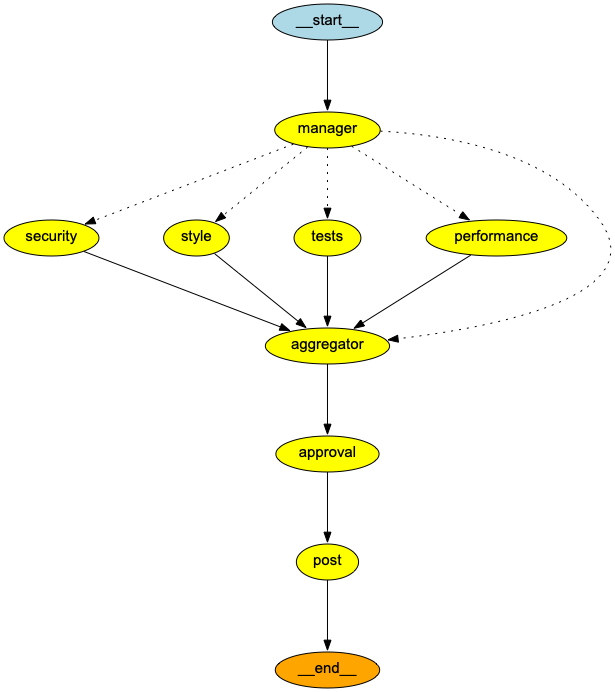

In [17]:
from IPython.display import Image, display
png_bytes = app.get_graph().draw_png() 
display(Image(png_bytes))

In [19]:
def print_review_trace(state: dict):
    print("="*70)
    print("COORDINATION -- Manager's plan")
    print("="*70)
    print(f"Specialists called: {state['plan']}")
    print()

    print("="*70)
    print("COMMUNICATION -- each specialist's dedicated findings")
    print("="*70)
    specialist_keys = {
        "security":    "security_findings",
        "style":       "style_findings",
        "tests":       "test_findings",
        "docs":        "docs_findings",
        "performance": "performance_findings",
    }
    for name, key in specialist_keys.items():
        value = state.get(key, "")
        if name in state["plan"]:
            print(f"\n--- {name.upper()} (ran) ---")
            print(value[:300] + ("..." if len(value) > 300 else ""))
        else:
            print(f"\n--- {name.upper()} (skipped -- not in plan) ---")

    print("\n" + "="*70)
    print("COOPERATION -- Aggregator's final synthesized verdict")
    print("="*70)
    print(state["final_comment"])

In [22]:

initial_state = {
    "pr_number": 1, "pr_details": {}, "pr_files": [], "plan": [],
    "security_findings": "", "style_findings": "", "test_findings": "",
    "docs_findings": "", "performance_findings": "",
    "final_comment": "", "approved": False,
}

In [23]:
app.invoke(initial_state)

PR not approved. No comment posted.


{'pr_number': 1,
 'pr_details': {'title': 'updated the code',
  'author': 'rahul8879',
  'body': 'Update the payment module because I need ',
  'branch': 'feature/database'},
 'pr_files': [{'filename': 'auth.py',
   'patch': '@@ -0,0 +1,49 @@\n+# auth.py\n+# ⚠️ WARNING: This is intentionally buggy code for CodeSentinel demo purposes only\n+\n+import sqlite3\n+import hashlib\n+\n+# Bug 1: Hardcoded secrets\n+SECRET_KEY   = "supersecret123"\n+ADMIN_PASS   = "admin123"\n+DB_PASSWORD  = "root1234"\n+\n+# Bug 2: Weak hashing — MD5 is broken\n+def hash_password(password: str) -> str:\n+    return hashlib.md5(password.encode()).hexdigest()\n+\n+# Bug 3: No rate limiting — brute force possible\n+def login(username: str, password: str) -> dict:\n+    conn = sqlite3.connect("users.db")\n+    cursor = conn.cursor()\n+\n+    # Bug 4: SQL Injection\n+    query = f"SELECT * FROM users WHERE username = \'{username}\' AND password = \'{hash_password(password)}\'"\n+    cursor.execute(query)\n+    user

In [ ]:
{'pr_number': 11,
 'pr_details': {'title': 'I am testing my agent is working or not',
  'author': 'rahul8879',
  'body': 'Seems I have some issue in my code.',
  'branch': 'feature/mas_testing'},
 'pr_files': [{'filename': 'orders.py',
   'patch': '@@ -45,9 +45,10 @@ def get_order(order_id: str):\n \n     # Bug 5: SQL injection\n     # Bug 6: No auth check — any user can see any order\n-    query = f"SELECT * FROM orders WHERE id = 3123123"\n+    query = f"SELECT * FROM orders WHERE id = somethign bad"\n     # here is my password : Rahul\n     result = conn.execute(query).fetchone()\n+    # doing some basic testing\n \n     return {"order": result}\n '}],
 'plan': ['security'],
 'security_findings': 'In the provided code snippet from `orders.py`, there are several security issues:\n\n1. **SQL Injection (Line 48):**\n   - The query construction `query = f"SELECT * FROM orders WHERE id = somethign bad"` is vulnerable to SQL injection. The `order_id` should be parameterized to prevent injection attacks. Instead of using string interpolation, use parameterized queries provided by your database library.\n\n   Example fix using parameterized queries:\n   ```python\n   query = "SELECT * FROM orders WHERE id = ?"\n   result = conn.execute(query, (order_id,)).fetchone()\n   ```\n\n2. **Missing Authentication Check (Line 47):**\n   - There is no authentication or authorization check to ensure that the user requesting the order has the right to view it. This means any user can potentially access any order. Implement a check to verify that the user has the necessary permissions to view the order.\n\n3. **Hardcoded Secret (Line 50):**\n   - The comment `# here is my password : Rahul` suggests that a password is hardcoded in the code. Even though it is commented out, it is a bad practice to include any sensitive information in the codebase. Remove any hardcoded secrets and use environment variables or a secure vault to manage sensitive information.\n\nAddressing these issues will help improve the security of the application.',
 'style_findings': '',
 'test_findings': '',
 'docs_findings': '',
 'performance_findings': '',
 'final_comment': '## CodeSentinel Review — NEEDS_CHANGES\n**Severity:** HIGH\n\nThe code contains critical security vulnerabilities, including SQL injection, lack of authentication checks, and hardcoded secrets. These issues must be addressed to prevent potential security breaches. Implement parameterized queries, add authentication checks, and remove hardcoded sensitive information to enhance security.\n\n---\nSecurity: In the provided code snippet from `orders.py`, there are several security issues:\n\n1. **SQL Injection (Line 48):**\n   - The query construction `query = f"SELECT * FROM orders WHERE id = somethign bad"` is vulnerable to SQL injection. The `order_id` should be parameterized to prevent injection attacks. Instead of using string interpolation, use parameterized queries provided by your database library.\n\n   Example fix using parameterized queries:\n   ```python\n   query = "SELECT * FROM orders WHERE id = ?"\n   result = conn.execute(query, (order_id,)).fetchone()\n   ```\n\n2. **Missing Authentication Check (Line 47):**\n   - There is no authentication or authorization check to ensure that the user requesting the order has the right to view it. This means any user can potentially access any order. Implement a check to verify that the user has the necessary permissions to view the order.\n\n3. **Hardcoded Secret (Line 50):**\n   - The comment `# here is my password : Rahul` suggests that a password is hardcoded in the code. Even though it is commented out, it is a bad practice to include any sensitive information in the codebase. Remove any hardcoded secrets and use environment variables or a secure vault to manage sensitive information.\n\nAddressing these issues will help improve the security of the application.',
 'approved': False}

In [ ]:
{'pr_number': 1,
 'pr_details': {'title': 'updated the code',
  'author': 'rahul8879',
  'body': 'Update the payment module because I need ',
  'branch': 'feature/database'},
 'pr_files': [{'filename': 'auth.py',
   'patch': '@@ -0,0 +1,49 @@\n+# auth.py\n+# ⚠️ WARNING: This is intentionally buggy code for CodeSentinel demo purposes only\n+\n+import sqlite3\n+import hashlib\n+\n+# Bug 1: Hardcoded secrets\n+SECRET_KEY   = "supersecret123"\n+ADMIN_PASS   = "admin123"\n+DB_PASSWORD  = "root1234"\n+\n+# Bug 2: Weak hashing — MD5 is broken\n+def hash_password(password: str) -> str:\n+    return hashlib.md5(password.encode()).hexdigest()\n+\n+# Bug 3: No rate limiting — brute force possible\n+def login(username: str, password: str) -> dict:\n+    conn = sqlite3.connect("users.db")\n+    cursor = conn.cursor()\n+\n+    # Bug 4: SQL Injection\n+    query = f"SELECT * FROM users WHERE username = \'{username}\' AND password = \'{hash_password(password)}\'"\n+    cursor.execute(query)\n+    user = cursor.fetchone()\n+    conn.close()\n+\n+    if user:\n+        return {"status": "success", "token": SECRET_KEY}\n+    return {"status": "failed"}\n+\n+# Bug 5: Weak password validation — accepts anything\n+def register(username: str, password: str) -> dict:\n+    if len(password) < 3:   # ← 3 chars enough!\n+        return {"error": "Password too short"}\n+\n+    conn = sqlite3.connect("users.db")\n+    cursor = conn.cursor()\n+\n+    # Bug 6: No duplicate username check\n+    cursor.execute(\n+        f"INSERT INTO users VALUES (\'{username}\', \'{hash_password(password)}\')"\n+    )\n+    conn.commit()\n+    conn.close()\n+    return {"status": "registered"}\n+\n+# Bug 7: Admin check hardcoded\n+def is_admin(password: str) -> bool:\n+    return password == ADMIN_PASS\n\\ No newline at end of file'},
  {'filename': 'payments.py',
   'patch': '@@ -14,6 +14,7 @@ def charge_payment(user_id: int, amount: float, card_number: str, cvv: str):\n     # Bug 3: No idempotency — double charging possible if called twice\n \n     conn = get_connection()\n+    # kets add one more bad things here\n \n     # Bug 4: SQL injection via f-string\n     query = f"INSERT INTO orders (user_id, product, amount, status) VALUES ({user_id}, \'charge\', {amount}, \'completed\')"'}],
 'plan': ['security', 'tests'],
 'security_findings': '### File: auth.py\n\n**Line 6-8: Hardcoded Secrets**\n- The file contains hardcoded secrets such as `SECRET_KEY`, `ADMIN_PASS`, and `DB_PASSWORD`. These should be stored securely using environment variables or a secrets management tool to prevent unauthorized access.\n\n**Line 13: Weak Hashing**\n- The `hash_password` function uses MD5 for hashing passwords, which is considered insecure due to its vulnerability to collision attacks. A stronger hashing algorithm like bcrypt or Argon2 should be used.\n\n**Line 18: Missing Rate Limiting**\n- The `login` function lacks rate limiting, making it susceptible to brute force attacks. Implementing rate limiting or account lockout mechanisms would mitigate this risk.\n\n### File: payments.py\n\n**Line 19: SQL Injection**\n- The query in the `charge_payment` function is constructed using an f-string, which is vulnerable to SQL injection attacks. User input should be handled safely using parameterized queries or prepared statements to prevent this vulnerability.',
 'style_findings': '',
 'test_findings': 'In the provided code snippets, there are a few areas where new logic has been introduced without corresponding tests, as well as potential edge cases that appear untested:\n\n1. **auth.py:**\n   - The `hash_password` function uses MD5 for hashing passwords. While the function itself is simple, there should be tests to ensure that it consistently produces the same hash for the same input and different hashes for different inputs. Edge cases such as empty strings or very long strings should also be tested.\n   - The `login` function is incomplete (`def login(username: str, password: str) -> dic`). Once completed, it will need tests to cover various scenarios, such as:\n     - Correct username and password.\n     - Incorrect username and/or password.\n     - Edge cases like empty username or password.\n     - Handling of special characters in username and password.\n\n2. **payments.py:**\n   - The `charge_payment` function has a comment indicating a potential new issue ("kets add one more bad things here"). If new logic is added here, it should be accompanied by tests to ensure it behaves as expected.\n   - The SQL injection vulnerability in the `query` string should be tested by attempting to inject SQL commands through the `user_id` or `amount` parameters. Tests should verify that the function handles such inputs safely, even though the current implementation is vulnerable.\n\nOverall, the code snippets lack tests for both the existing and potential new logic, especially concerning edge cases and vulnerabilities.',
 'docs_findings': '',
 'performance_findings': '',
 'final_comment': '## CodeSentinel Review — NEEDS_CHANGES\n**Severity:** HIGH\n\nThe code contains several critical security vulnerabilities, including hardcoded secrets, weak password hashing, lack of rate limiting, and SQL injection risks. Additionally, there is a lack of comprehensive testing for new and existing logic, particularly around security-sensitive areas. These issues must be addressed to ensure the application\'s security and reliability.\n\n---\nSecurity: ### File: auth.py\n\n**Line 6-8: Hardcoded Secrets**\n- The file contains hardcoded secrets such as `SECRET_KEY`, `ADMIN_PASS`, and `DB_PASSWORD`. These should be stored securely using environment variables or a secrets management tool to prevent unauthorized access.\n\n**Line 13: Weak Hashing**\n- The `hash_password` function uses MD5 for hashing passwords, which is considered insecure due to its vulnerability to collision attacks. A stronger hashing algorithm like bcrypt or Argon2 should be used.\n\n**Line 18: Missing Rate Limiting**\n- The `login` function lacks rate limiting, making it susceptible to brute force attacks. Implementing rate limiting or account lockout mechanisms would mitigate this risk.\n\n### File: payments.py\n\n**Line 19: SQL Injection**\n- The query in the `charge_payment` function is constructed using an f-string, which is vulnerable to SQL injection attacks. User input should be handled safely using parameterized queries or prepared statements to prevent this vulnerability.\n\nTests: In the provided code snippets, there are a few areas where new logic has been introduced without corresponding tests, as well as potential edge cases that appear untested:\n\n1. **auth.py:**\n   - The `hash_password` function uses MD5 for hashing passwords. While the function itself is simple, there should be tests to ensure that it consistently produces the same hash for the same input and different hashes for different inputs. Edge cases such as empty strings or very long strings should also be tested.\n   - The `login` function is incomplete (`def login(username: str, password: str) -> dic`). Once completed, it will need tests to cover various scenarios, such as:\n     - Correct username and password.\n     - Incorrect username and/or password.\n     - Edge cases like empty username or password.\n     - Handling of special characters in username and password.\n\n2. **payments.py:**\n   - The `charge_payment` function has a comment indicating a potential new issue ("kets add one more bad things here"). If new logic is added here, it should be accompanied by tests to ensure it behaves as expected.\n   - The SQL injection vulnerability in the `query` string should be tested by attempting to inject SQL commands through the `user_id` or `amount` parameters. Tests should verify that the function handles such inputs safely, even though the current implementation is vulnerable.\n\nOverall, the code snippets lack tests for both the existing and potential new logic, especially concerning edge cases and vulnerabilities.',
 'approved': False}

In [26]:
from IPython.display import HTML, display, clear_output
import time

NODE_POSITIONS = {
    "manager":     (300, 20),
    "security":    (20, 120),
    "style":       (170, 120),
    "tests":       (320, 120),
    "docs":        (470, 120),
    "performance": (620, 120),
    "aggregator":  (300, 220),
    "approval":    (300, 300),
    "post":        (300, 380),
}

# Which C each node represents
NODE_CCC = {
    "manager": "Coordination",
    "security": "Communication", "style": "Communication", "tests": "Communication",
    "docs": "Communication", "performance": "Communication",
    "aggregator": "Cooperation",
    "approval": "-", "post": "-",
}

# Which C each state key represents
STATE_KEY_CCC = {
    "plan": "Coordination",
    "security_findings": "Communication", "style_findings": "Communication",
    "test_findings": "Communication", "docs_findings": "Communication",
    "performance_findings": "Communication",
    "final_comment": "Cooperation",
}

STATE_KEYS = list(STATE_KEY_CCC.keys())

CCC_COLOR = {
    "Coordination": "#7F77DD",   # purple
    "Communication": "#1D9E75",  # teal
    "Cooperation": "#D85A30",    # coral
    "-": "#888780",
}

def render_graph_state(completed: set, active: set):
    boxes = ""
    for name, (x, y) in NODE_POSITIONS.items():
        fill = "#EF9F27" if name in active else ("#1D9E75" if name in completed else "#D3D1C7")
        ccc = NODE_CCC[name]
        boxes += f'''<div style="position:absolute; left:{x}px; top:{y}px;
            width:120px; height:56px; background:{fill}; border-radius:8px;
            display:flex; flex-direction:column; align-items:center; justify-content:center;
            font-family:sans-serif;">
            <div style="font-size:13px; color:#1a1a1a;">{name}</div>
            <div style="font-size:10px; color:#333;">{ccc}</div>
        </div>'''
    return f'<div style="position:relative; width:700px; height:460px;">{boxes}</div>'

def render_blackboard(state: dict, just_written: set):
    rows = ""
    for key in STATE_KEYS:
        value = state.get(key, "")
        is_empty = (value == "" or value == [])
        just_now = key in just_written
        bg = "#EF9F27" if just_now else ("#D3D1C7" if is_empty else "#1D9E75")
        ccc = STATE_KEY_CCC[key]
        ccc_color = CCC_COLOR[ccc]
        preview = "(empty)" if is_empty else (str(value)[:55].replace("\n", " ") + "...")
        rows += f'''<tr>
            <td style="padding:4px 10px; font-family:monospace; font-size:12px;">{key}</td>
            <td style="padding:4px 10px; background:{ccc_color}; border-radius:4px;
                font-size:11px; color:#fff; text-align:center;">{ccc}</td>
            <td style="padding:4px 10px; background:{bg}; border-radius:4px;
                font-size:12px; color:#1a1a1a;">{preview}</td>
        </tr>'''
    header = '''<tr>
        <td style="padding:4px 10px; font-family:sans-serif; font-size:11px; font-weight:bold;">Key</td>
        <td style="padding:4px 10px; font-family:sans-serif; font-size:11px; font-weight:bold;">C</td>
        <td style="padding:4px 10px; font-family:sans-serif; font-size:11px; font-weight:bold;">Value</td>
        </tr>'''
    return f'''<table style="border-collapse:separate; border-spacing:0 4px; width:700px;">
        {header}{rows}</table>'''

# --- Live run ---
initial_state = {
    "pr_number": 11, "pr_details": {}, "pr_files": [], "plan": [],
    "security_findings": "", "style_findings": "", "test_findings": "",
    "docs_findings": "", "performance_findings": "",
    "final_comment": "", "approved": False,
}

completed = set()
current_state = dict(initial_state)

for step in app.stream(initial_state, stream_mode="updates"):
    active = set(step.keys())
    just_written = set()
    for node_name, node_output in step.items():
        for k, v in node_output.items():
            current_state[k] = v
            just_written.add(k)

    clear_output(wait=True)
    html = "<h4 style='font-family:sans-serif;'>Graph -- purple=Coordination, teal=Communication, coral=Cooperation</h4>"
    html += render_graph_state(completed, active)
    html += "<h4 style='font-family:sans-serif;'>Shared blackboard (ReviewState)</h4>"
    html += render_blackboard(current_state, just_written)
    display(HTML(html))
    time.sleep(1.0)

    completed |= active

clear_output(wait=True)
final_html = "<h4 style='font-family:sans-serif;'>Graph -- purple=Coordination, teal=Communication, coral=Cooperation</h4>"
final_html += render_graph_state(completed, set())
final_html += "<h4 style='font-family:sans-serif;'>Shared blackboard (ReviewState) -- final</h4>"
final_html += render_blackboard(current_state, set())
display(HTML(final_html))
print("Done.")

Key,C,Value
plan,Coordination,['security']...
security_findings,Communication,"In the provided code snippet from `orders.py`, there ar..."
style_findings,Communication,(empty)
test_findings,Communication,(empty)
docs_findings,Communication,(empty)
performance_findings,Communication,(empty)
final_comment,Cooperation,## CodeSentinel Review — NEEDS_CHANGES **Severity:** HI...


Posted final comment to PR.


AttributeError: 'NoneType' object has no attribute 'items'

In [18]:
pip install pygraphviz


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
